In [1]:
import os
import sys

# Get the path of the current file or notebook
current_path = os.path.abspath(
    __file__ if "__file__" in locals() else os.getcwd()
)

# Get the parent directory
parent_dir = os.path.dirname(current_path)
print(f"Parent directory: {parent_dir}")
# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import time

import matplotlib.pyplot as plt
from torch import Tensor, cat, device
from torch import empty as empty_tensor
from torch import float32 as torch_float32
from torch import float64 as torch_float64
from torch import get_num_threads, pi, tensor
from torch import zeros as zeros_tensor

from scanner_modeling._convex_hull._convex_hull_functions import (
    convex_hull_2d,
    sort_points_for_hull_2d,
)
from scanner_modeling._plot._mpl_plot_system import (
    plot_polygons_from_vertices_mpl,
    plot_scanner_from_vertices_2d_mpl,
)
from scanner_modeling._raytracer_2d._local_functions import (
    line_segments_t,
    rays_2d_batch,
    rays_edges_t_subdivisions,
    rays_intersection_lengths,
    sfov_properties,
    subdivision_grid_rectangle,
    subdivision_vertices_rectangle,
)
from scanner_modeling.geometry_2d import (
    fov_corners_vertices_2d,
    fov_tensor_dict,
    load_scanner_geometry_from_layout,
    load_scanner_layouts,
    polygon_edges_from_vertices_2d_batch,
    polygon_to_points_angular_span_2d_batch,
    reduced_scanner_objects_ids_local,
)

Parent directory: /home/fanghan/Work/spebt/packages/pymatcal


In [2]:
default_device = device("cpu")

scanner_layout_file_relative_path = (
    "../scanner_layouts/scanner_layouts_e1531c3444e51439add2f18f5714fc50.tensor"
)
# Get the dir and filename from the relative path
scanner_layout_dir = os.path.dirname(scanner_layout_file_relative_path)
scanner_layout_filename = os.path.basename(scanner_layout_file_relative_path)
layout_idx = 0
start_time = time.time()

scanner_layouts, layouts_md5 = load_scanner_layouts(
    scanner_layout_dir,
    scanner_layout_filename,
)


# mu_dict = {"plate": 3.5, "crystal": 0.475}  # mm^-1
mu_dict = tensor([3.5, 0.475], device=default_device)

fov_dict = fov_tensor_dict((512, 512), (128, 128), (0.0, 0.0), (8, 8))

crystal_n_subs = (5, 5)
# crystal_n_subs = (9, 9)
sfov_pxs_ids, sfov_pixels_batch, sfov_corners_batch = sfov_properties(fov_dict)
n_sfov = int(fov_dict["n subdivisions"].prod())
sfov_pxs_ids_1d = (
    sfov_pxs_ids[:, :, 0] * fov_dict["n pixels"][0] + sfov_pxs_ids[:, :, 1]
)

ppdf = empty_tensor(int(fov_dict["n pixels"].prod()), dtype=torch_float64)

print(f"Number of FOV Blocks:               {n_sfov}")
print(f"FOV Block Size:                     {sfov_pixels_batch.shape[1]}")
print(f"Number of Subdivisions per Crystal: {crystal_n_subs}")

# from torch import set_num_threads,set_default_dtype
# torch.set_default_dtype(torch_float64)
# set_num_threads(16)
# set_default_dtype(torch_float64)

print(
    f"PyTorch is set to use {get_num_threads()} threads for intra-op parallelism."
)

subdivision_grid = subdivision_grid_rectangle(crystal_n_subs)

(
    plate_objects_vertices,
    crystal_objects_vertices,
    plate_objects_edges,
    crystal_objects_edges,
) = load_scanner_geometry_from_layout(layout_idx, scanner_layouts)

# crystal_objects_vertices = crystal_objects_vertices.to(torch_float64)
# crystal_objects_edges = crystal_objects_edges.to(torch_float64)
# plate_objects_vertices = plate_objects_vertices.to(torch_float64)
# plate_objects_edges = plate_objects_edges.to(torch_float64)
crystal_idx = 234
mu_dict = mu_dict.to(default_device)
subdivision_grid = subdivision_grid.to(default_device)
# sfov_pxs_ids_1d = sfov_pxs_ids_1d.to("cpu")

sfov_pixels_batch = sfov_pixels_batch.to(default_device)
plate_objects_vertices = plate_objects_vertices.to(default_device)
crystal_objects_vertices = crystal_objects_vertices.to(default_device)
plate_objects_edges = plate_objects_edges.to(default_device)
crystal_objects_edges = crystal_objects_edges.to(default_device)
subdivision_grid = subdivision_grid.to(default_device)
sfov_corners_batch = sfov_corners_batch.to(default_device)
# for sfov_idx in range(n_sfov):


Number of FOV Blocks:               64
FOV Block Size:                     4096
Number of Subdivisions per Crystal: (5, 5)
PyTorch is set to use 8 threads for intra-op parallelism.


In [3]:
# ppdf = zeros_tensor(
#     int(fov_dict["n pixels"].prod()), dtype=torch_float64, device=default_device
# )

sfov_n_pxs = int((fov_dict["n pixels"] / fov_dict["n subdivisions"]).prod())
ppdf_sfov_list = []
exp_crystal_sfov_tensor = zeros_tensor((0, sfov_n_pxs))
exp_plate_sfov_tensor = zeros_tensor((0, sfov_n_pxs))
sfov_reduced_crystal_ids_list = []
sfov_reduced_plate_ids_list = []
sfov_hull_list = []

sub_crystals_vertices = subdivision_vertices_rectangle(
    crystal_objects_vertices[crystal_idx], subdivision_grid
)
for sfov_idx in range(n_sfov):
    print(f"Processing SFOV {sfov_idx + 1} of {n_sfov}...")
    local_hull = convex_hull_2d(
        sort_points_for_hull_2d(
            cat(
                (
                    sfov_corners_batch[sfov_idx],
                    crystal_objects_vertices[crystal_idx],
                ),
                dim=0,
            )
        )
    )
    sfov_hull_list.append(local_hull)
    reduced_plate_objects_ids, reduced_crystal_objects_ids = (
        reduced_scanner_objects_ids_local(
            local_hull,
            plate_objects_vertices,
            crystal_objects_vertices,
            plate_objects_edges,
            crystal_objects_edges,
            device=default_device,
        )
    )
    sfov_reduced_crystal_ids_list.append(reduced_crystal_objects_ids)
    sfov_reduced_plate_ids_list.append(reduced_plate_objects_ids)
    # reduced_plate_objects_edges_ids = (
    #     reduced_plate_objects_ids.repeat_interleave(4, dim=0).squeeze()
    # )
    # reduced_crystal_objects_edges_ids = (
    #     reduced_crystal_objects_ids.repeat_interleave(4, dim=0).squeeze()
    # )
    print(f"Reduced plate objects IDs: {reduced_plate_objects_ids.tolist()}")
    print(f"Reduced crystal IDs: {reduced_crystal_objects_ids.tolist()}")
    reduced_plate_edges = plate_objects_edges[reduced_plate_objects_ids]
    reduced_crystal_edges = crystal_objects_edges[reduced_crystal_objects_ids]

    sub_crystals_edges = polygon_edges_from_vertices_2d_batch(sub_crystals_vertices)

    pa_batch = sfov_pixels_batch[sfov_idx]
    pb_batch = sub_crystals_vertices.mean(dim=1)

    rays = rays_2d_batch(pa_batch, pb_batch)
    rays_plates_transmission_t = line_segments_t(
        rays.view(-1, 2, 2), reduced_plate_edges.view(-1, 2, 2)
    )

    rays_crystal_transmission_t = line_segments_t(
        rays.view(-1, 2, 2), reduced_crystal_edges.view(-1, 2, 2)
    )
    print(f"Rays shape: {rays.shape}")
    print(f"Rays plates transmission t shape: {rays_plates_transmission_t.shape}")
    print(f"Rays crystal transmission t shape: {rays_crystal_transmission_t.shape}")
    rays_sub_crystal_t = rays_edges_t_subdivisions(rays, sub_crystals_edges)

    intersection_length_plates = rays_intersection_lengths(
        rays, rays_plates_transmission_t
    ).view(rays.shape[0], rays.shape[1], -1)
    intersection_length_crystals = rays_intersection_lengths(
        rays, rays_crystal_transmission_t
    ).view(rays.shape[0], rays.shape[1], -1)
    print(f"Intersection length plates shape: {intersection_length_plates.shape}")
    print(f"Intersection length crystals shape: {intersection_length_crystals.shape}")
    intersection_length_subdivisions = rays_intersection_lengths(
        rays, rays_sub_crystal_t
    ).view(rays.shape[0], rays.shape[1])

    subdivision_rads_span = polygon_to_points_angular_span_2d_batch(
        sub_crystals_vertices, pa_batch
    )

    sum_plate_exponent = (intersection_length_plates * mu_dict[0]).sum(dim=2)
    sum_crystal_exponent = (intersection_length_crystals * mu_dict[1]).sum(dim=2)
    print(f"Sum plate exponent shape: {sum_plate_exponent.shape}")
    print(f"Sum crystal exponent shape: {sum_crystal_exponent.shape}")
    exp_crystal_sfov_tensor = cat(
        (
            exp_crystal_sfov_tensor,
            (sum_crystal_exponent.sum(1)).unsqueeze(0),
        ),
        dim=0,
    )
    exp_plate_sfov_tensor = cat(
        (
            exp_plate_sfov_tensor,
            (sum_plate_exponent.sum(1)).unsqueeze(0),
        ),
        dim=0,
    )
    subdivision_exponent = intersection_length_subdivisions * float(mu_dict[1])
    angular_term = subdivision_rads_span / (2 * pi)

    # ppdf[sfov_pxs_ids_1d[sfov_idx]] = (
    #     (-sum_plate_exponent - sum_crystal_exponent).exp()
    #     * (subdivision_exponent.exp() - 1)
    #     * angular_term
    # ).sum(dim=1)
    ppdf_sfov_list.append(
        (
            (-sum_plate_exponent - sum_crystal_exponent).exp()
            * (subdivision_exponent.exp() - 1)
            * angular_term
        ).sum(dim=1)
    )

Processing SFOV 1 of 64...
Reduced plate objects IDs: [57, 58]
Reduced crystal IDs: [152, 153, 168, 169, 185, 186, 201, 202, 218, 234]
Rays shape: torch.Size([4096, 25, 2, 2])
Rays plates transmission t shape: torch.Size([102400, 8])
Rays crystal transmission t shape: torch.Size([102400, 40])
Intersection length plates shape: torch.Size([4096, 25, 2])
Intersection length crystals shape: torch.Size([4096, 25, 10])
Sum plate exponent shape: torch.Size([4096, 25])
Sum crystal exponent shape: torch.Size([4096, 25])
Processing SFOV 2 of 64...
Reduced plate objects IDs: [58, 59]
Reduced crystal IDs: [152, 153, 168, 169, 185, 186, 201, 202, 218, 234]
Rays shape: torch.Size([4096, 25, 2, 2])
Rays plates transmission t shape: torch.Size([102400, 8])
Rays crystal transmission t shape: torch.Size([102400, 40])
Intersection length plates shape: torch.Size([4096, 25, 2])
Intersection length crystals shape: torch.Size([4096, 25, 10])
Sum plate exponent shape: torch.Size([4096, 25])
Sum crystal expon

Selected SFOV 49 reduced crystal IDs: tensor([154, 170, 186, 202, 218, 234])


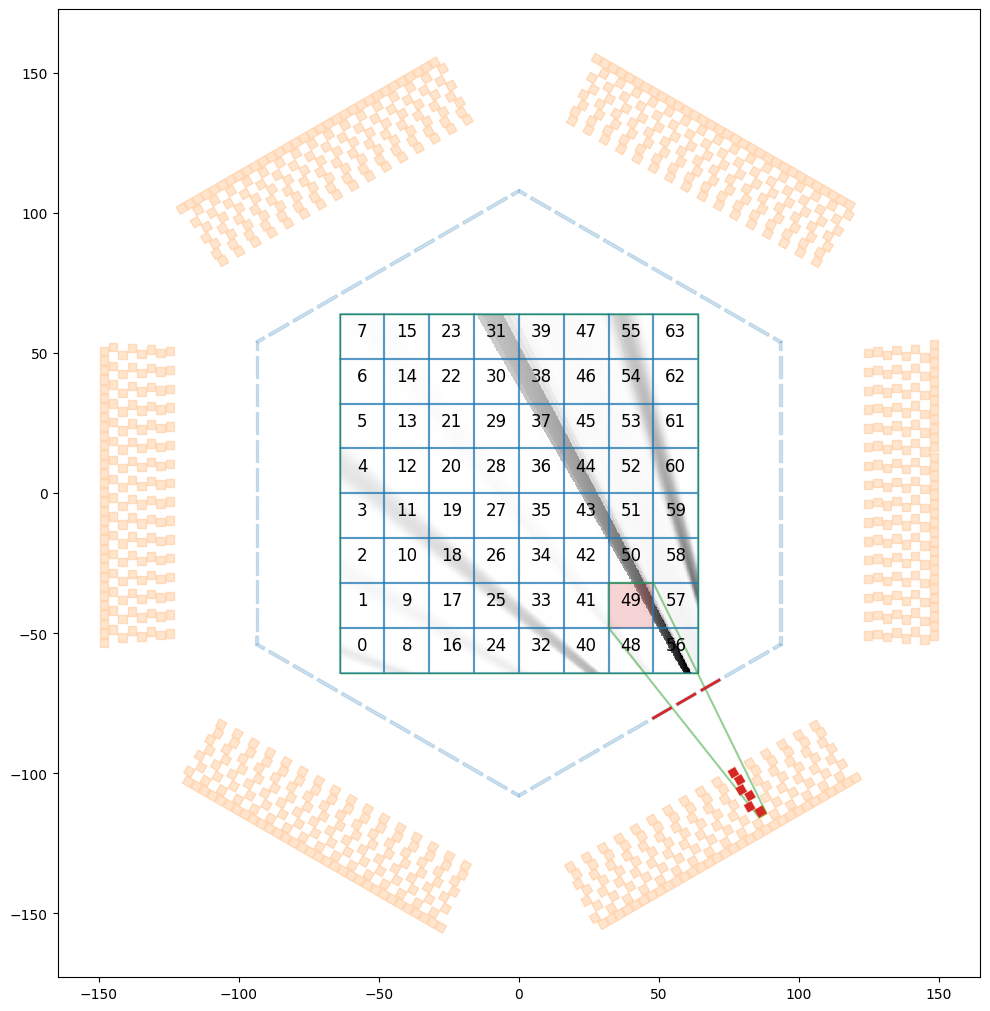

In [4]:


plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
for sfov_idx, ppdf_sfov in enumerate(ppdf_sfov_list):
    sfov_corners = sfov_corners_batch[sfov_idx].cpu().numpy()
    sfov_center = sfov_corners.mean(axis=0)
    sfov_extent = (
        sfov_corners[:, 0].min(),
        sfov_corners[:, 0].max(),
        sfov_corners[:, 1].min(),
        sfov_corners[:, 1].max(),
    )
    ax.imshow(
        ppdf_sfov.cpu()
        .view(
            fov_dict["n pixels"][0] // fov_dict["n subdivisions"][0],
            fov_dict["n pixels"][1] // fov_dict["n subdivisions"][1],
        )
        .T,
        origin="lower",
        extent=sfov_extent,
        cmap="gray_r",
        interpolation="none",
        vmin=0,
        vmax=1e-3,
    )
    ax.annotate(
        f"{sfov_idx}",
        sfov_center,
        textcoords="offset points",
        xytext=(0, 0),
        ha="center",
        fontsize=12,
        color="black",
    )

scanner_polycoll_dict = plot_scanner_from_vertices_2d_mpl(
    plate_objects_vertices, crystal_objects_vertices, ax, fov_dict, plate_alpha=0.2, crystal_alpha=0.2, fov_alpha=1
)
selected_crystal_polycoll = plot_polygons_from_vertices_mpl(
    crystal_objects_vertices[crystal_idx : crystal_idx + 1], ax, color="C1"
)

#Plot the SFOV frame
sfov_polycoll = plot_polygons_from_vertices_mpl(
    sfov_corners_batch, ax, ec="C0", fc="none", linewidth=1.5, alpha=0.5
)
selected_sfov_idx = 49
selected_sfov_polycoll = plot_polygons_from_vertices_mpl(
    sfov_corners_batch[selected_sfov_idx : selected_sfov_idx + 1],
    ax,
    ec="none",
    fc="C3",
    alpha=0.2
)
selected_sfov_crystal_ids = sfov_reduced_crystal_ids_list[selected_sfov_idx]
print(f"Selected SFOV {selected_sfov_idx} reduced crystal IDs: {selected_sfov_crystal_ids}")
selected_sfov_hull = sfov_hull_list[selected_sfov_idx]
selected_sfov_hull_polycoll = plot_polygons_from_vertices_mpl(
    selected_sfov_hull.unsqueeze(0), ax, ec="C2", fc="none", linewidth=1.5, alpha=0.5
)


selected_sfov_reduced_crystals_polycoll = plot_polygons_from_vertices_mpl(
    crystal_objects_vertices[selected_sfov_crystal_ids],
    ax,
    fc="C3",
    ec="none",
    alpha=1,
)
selected_sfov_reduced_plates_polycoll = plot_polygons_from_vertices_mpl(
    plate_objects_vertices[sfov_reduced_plate_ids_list[selected_sfov_idx]],
    ax,
    fc="C3",
    ec="none",
    alpha=1,
)

Selected SFOV 50 reduced crystal IDs: tensor([154, 155, 170, 186, 187, 202, 218, 234])


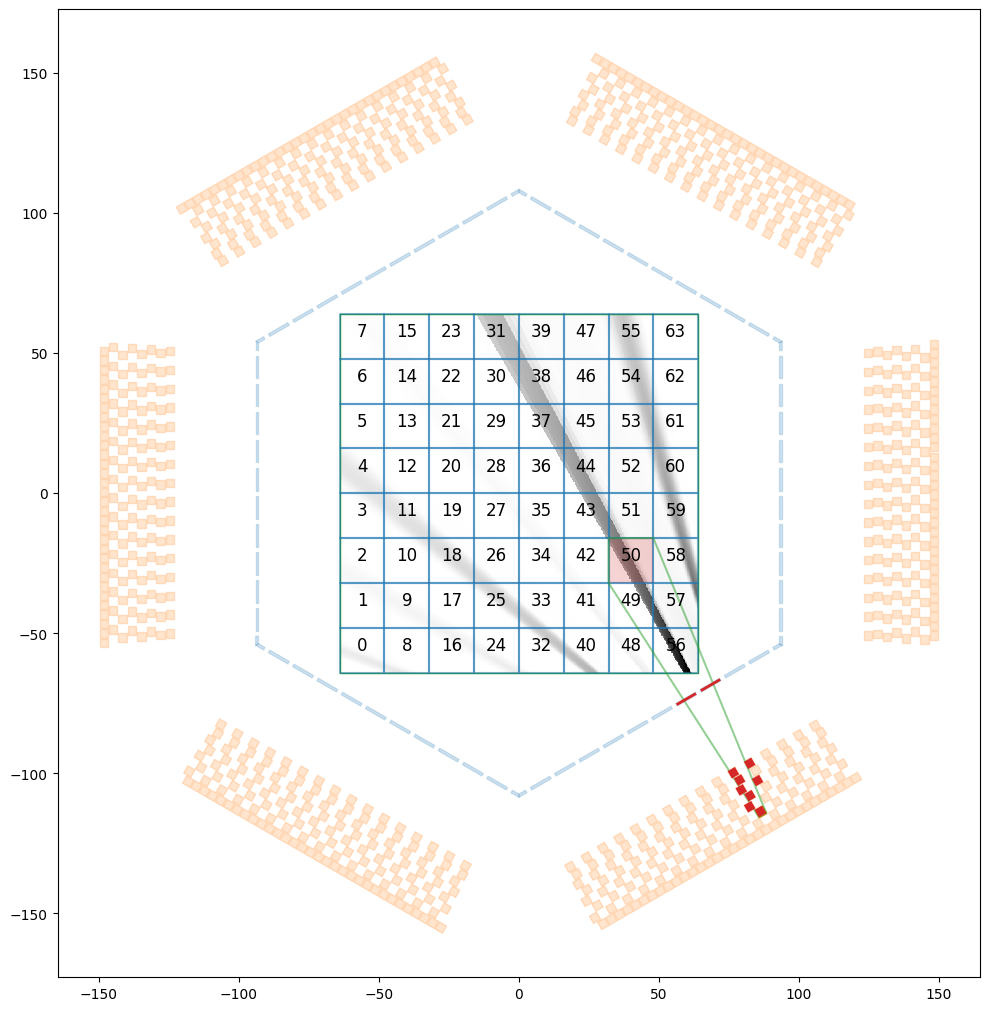

In [5]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
for sfov_idx, ppdf_sfov in enumerate(ppdf_sfov_list):
    sfov_corners = sfov_corners_batch[sfov_idx].cpu().numpy()
    sfov_center = sfov_corners.mean(axis=0)
    sfov_extent = (
        sfov_corners[:, 0].min(),
        sfov_corners[:, 0].max(),
        sfov_corners[:, 1].min(),
        sfov_corners[:, 1].max(),
    )
    ax.imshow(
        ppdf_sfov.cpu()
        .view(
            fov_dict["n pixels"][0] // fov_dict["n subdivisions"][0],
            fov_dict["n pixels"][1] // fov_dict["n subdivisions"][1],
        )
        .T,
        origin="lower",
        extent=sfov_extent,
        cmap="gray_r",
        interpolation="none",
        vmin=0,
        vmax=1e-3,
    )
    ax.annotate(
        f"{sfov_idx}",
        sfov_center,
        textcoords="offset points",
        xytext=(0, 0),
        ha="center",
        fontsize=12,
        color="black",
    )

scanner_polycoll_dict = plot_scanner_from_vertices_2d_mpl(
    plate_objects_vertices, crystal_objects_vertices, ax, fov_dict, plate_alpha=0.2, crystal_alpha=0.2, fov_alpha=1
)
selected_crystal_polycoll = plot_polygons_from_vertices_mpl(
    crystal_objects_vertices[crystal_idx : crystal_idx + 1], ax, color="C1"
)

#Plot the SFOV frame
sfov_polycoll = plot_polygons_from_vertices_mpl(
    sfov_corners_batch, ax, ec="C0", fc="none", linewidth=1.5, alpha=0.5
)
selected_sfov_idx = 50
selected_sfov_polycoll = plot_polygons_from_vertices_mpl(
    sfov_corners_batch[selected_sfov_idx : selected_sfov_idx + 1],
    ax,
    ec="none",
    fc="C3",
    alpha=0.2
)
selected_sfov_crystal_ids = sfov_reduced_crystal_ids_list[selected_sfov_idx]
print(f"Selected SFOV {selected_sfov_idx} reduced crystal IDs: {selected_sfov_crystal_ids}")
selected_sfov_hull = sfov_hull_list[selected_sfov_idx]
selected_sfov_hull_polycoll = plot_polygons_from_vertices_mpl(
    selected_sfov_hull.unsqueeze(0), ax, ec="C2", fc="none", linewidth=1.5, alpha=0.5
)


selected_sfov_reduced_crystals_polycoll = plot_polygons_from_vertices_mpl(
    crystal_objects_vertices[selected_sfov_crystal_ids],
    ax,
    fc="C3",
    ec="none",
    alpha=1,
)
selected_sfov_reduced_plates_polycoll = plot_polygons_from_vertices_mpl(
    plate_objects_vertices[sfov_reduced_plate_ids_list[selected_sfov_idx]],
    ax,
    fc="C3",
    ec="none",
    alpha=1,
)

Minimum value data_tensor: 0.0
Maximum value in data_tensor: 615.7015991210938


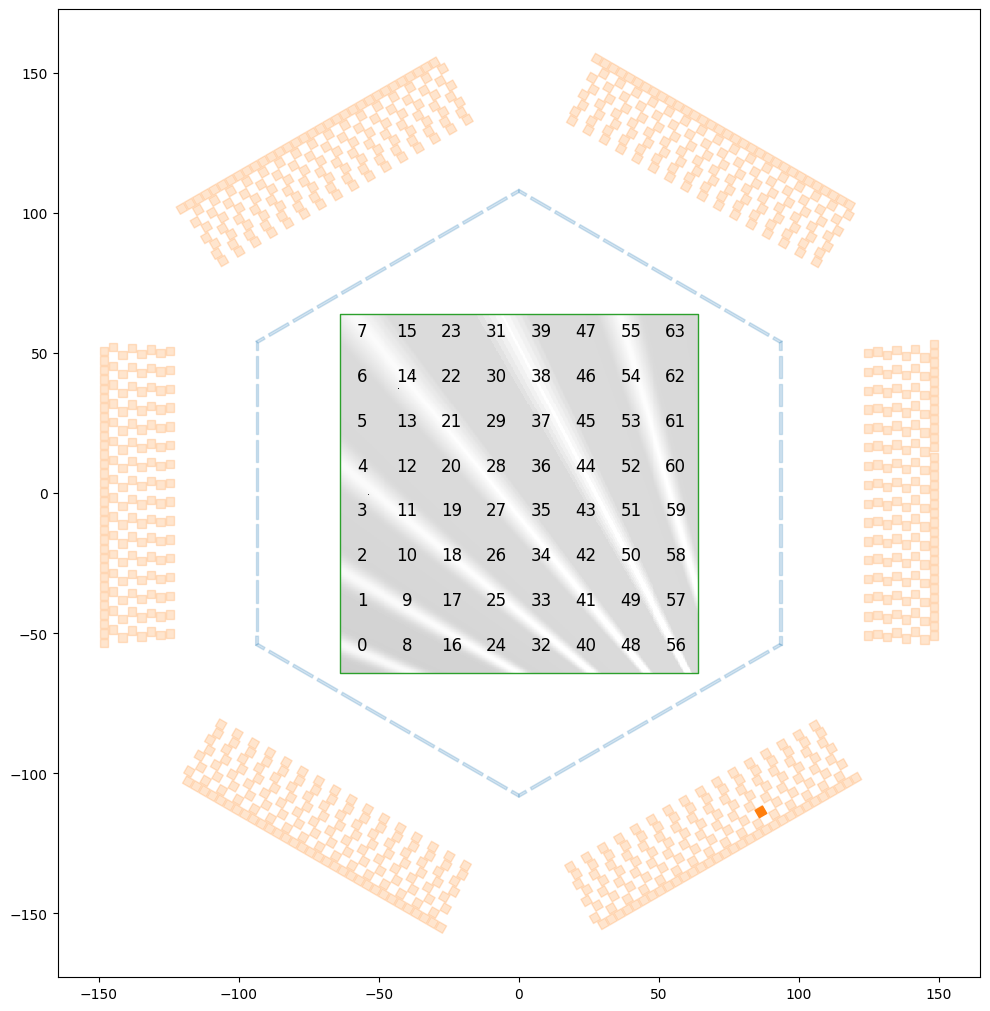

In [6]:
data_tensor = exp_plate_sfov_tensor
value_min = data_tensor.min().item()
value_max = data_tensor.max().item()
print(f"Minimum value data_tensor: {value_min}")
print(f"Maximum value in data_tensor: {value_max}")

plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
for sfov_idx, ppdf_sfov in enumerate(data_tensor):
    sfov_corners = sfov_corners_batch[sfov_idx].cpu().numpy()
    sfov_center = sfov_corners.mean(axis=0)
    sfov_extent = (
        sfov_corners[:, 0].min(),
        sfov_corners[:, 0].max(),
        sfov_corners[:, 1].min(),
        sfov_corners[:, 1].max(),
    )
    ax.imshow(
        ppdf_sfov.cpu()
        .view(
            fov_dict["n pixels"][0] // fov_dict["n subdivisions"][0],
            fov_dict["n pixels"][1] // fov_dict["n subdivisions"][1],
        )
        .T,
        origin="lower",
        extent=sfov_extent,
        cmap="gray_r",
        interpolation="none",
        vmin=value_min,
        vmax=value_max,
    )
    ax.annotate(
        f"{sfov_idx}",
        sfov_center,
        textcoords="offset points",
        xytext=(0, 0),
        ha="center",
        fontsize=12,
        color="black",
    )
scanner_polycoll_dict = plot_scanner_from_vertices_2d_mpl(
    plate_objects_vertices,
    crystal_objects_vertices,
    ax,
    fov_dict,
    plate_alpha=0.2,
    crystal_alpha=0.2,
    fov_alpha=1,
)
selected_crystal_polycoll = plot_polygons_from_vertices_mpl(
    crystal_objects_vertices[crystal_idx : crystal_idx + 1], ax, color="C1"
)

In [7]:
sfov_corners= sfov_corners_batch[15].cpu().numpy()
print(f"SFOV Corners: {sfov_corners[:,0].min()} {sfov_corners[:,0].max()}")
print(f"SFOV Corners: {sfov_corners[:,1].min()} {sfov_corners[:,1].max()}")

SFOV Corners: -48.0 -32.0
SFOV Corners: 48.0 64.0


In [8]:
print(f"SFOV Corners: {sfov_corners[:,1].min()} {sfov_corners[:,1].max()}")

SFOV Corners: 48.0 64.0


In [9]:
# Processing SFOV 1 of 64...
# Reduced plate objects IDs: [57, 58]
# Reduced crystal IDs: [152, 153, 168, 169, 185, 186, 201, 202, 218, 234]
# Rays shape: torch.Size([256, 81, 2, 2])
# Rays plates transmission t shape: torch.Size([20736, 32])
# Rays crystal transmission t shape: torch.Size([20736, 160])

print(256*81, 10*4)

20736 40


In [10]:
reduced_crystal_objects_ids = tensor([152, 153, 168, 169, 185, 186, 201, 202, 218, 234])
# reduced_crystal_objects_edges_ids = (
#     reduced_crystal_objects_ids.repeat_interleave(4, dim=0).squeeze()
# )
print(f"Reduced plate objects IDs: {reduced_plate_objects_ids.tolist()}")
print(f"Reduced crystal IDs: {reduced_crystal_objects_ids}")
# print(f"reduced_crystal_objects_edges_ids: {reduced_crystal_objects_edges_ids.tolist()}")
print(f"Crystal objects edges shape: {crystal_objects_edges.shape}")
reduced_crystal_edges = crystal_objects_edges[
    reduced_crystal_objects_ids
]
print(f"Reduced crystal edges shape: {reduced_crystal_edges.shape}")

Reduced plate objects IDs: [63]
Reduced crystal IDs: tensor([152, 153, 168, 169, 185, 186, 201, 202, 218, 234])
Crystal objects edges shape: torch.Size([864, 4, 2, 2])
Reduced crystal edges shape: torch.Size([10, 4, 2, 2])


In [11]:
print(ppdf_sfov_list[49].view(64, 64)[:,63])
print(ppdf_sfov_list[50].view(64, 64)[:,0])

tensor([5.5595e-07, 6.2149e-07, 7.1311e-07, 8.3526e-07, 9.6358e-07, 1.0557e-06,
        1.1164e-06, 1.1390e-06, 1.1398e-06, 1.1401e-06, 1.1402e-06, 1.1404e-06,
        1.1487e-06, 1.2205e-06, 1.3915e-06, 1.7344e-06, 2.3448e-06, 3.2374e-06,
        3.8151e-06, 4.0226e-06, 4.0211e-06, 4.0244e-06, 4.1964e-06, 4.5015e-06,
        5.0891e-06, 6.1912e-06, 8.4093e-06, 1.1531e-05, 1.3508e-05, 1.3753e-05,
        1.4297e-05, 1.4290e-05, 1.4283e-05, 1.4721e-05, 4.2295e-04, 4.2353e-04,
        5.2358e-04, 5.2549e-04, 5.2740e-04, 5.5346e-04, 5.5547e-04, 5.6451e-04,
        5.7336e-04, 5.8149e-04, 5.8841e-04, 5.9163e-04, 5.9404e-04, 5.9869e-04,
        6.0773e-04, 6.2263e-04, 6.4147e-04, 2.2908e-04, 2.4457e-04, 2.0915e-04,
        1.6162e-04, 1.5881e-04, 6.2444e-05, 6.4804e-05, 4.5569e-05, 4.2761e-05,
        3.4150e-05, 2.5021e-05, 2.5933e-05, 2.6861e-05], dtype=torch.float64)
tensor([5.9554e-07, 6.7746e-07, 7.9067e-07, 9.2551e-07, 1.0258e-06, 1.0942e-06,
        1.1316e-06, 1.1362e-06, 1.1365e-06

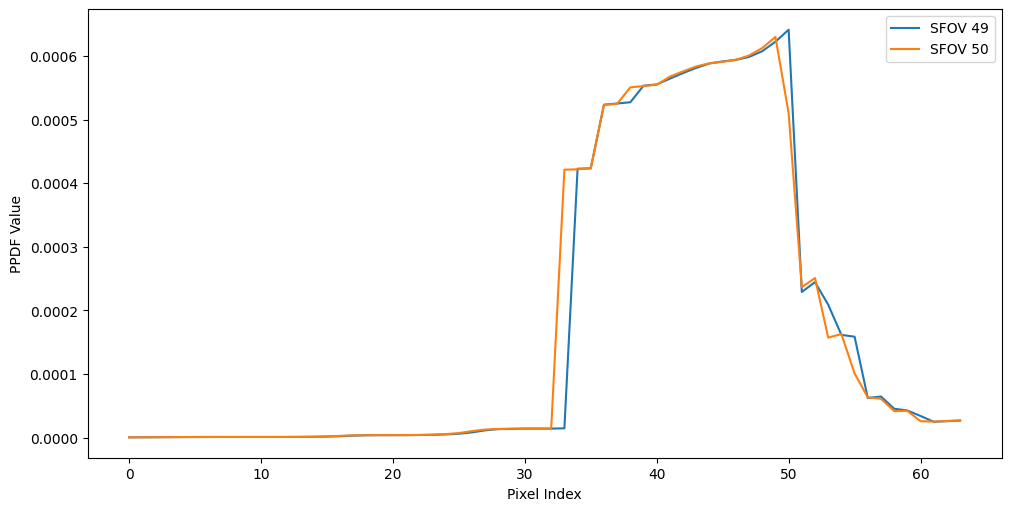

In [12]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
ax.plot(
    ppdf_sfov_list[49].view(64, 64)[:, 63].cpu().numpy(),
    label="SFOV 49",
    color="C0",
)
ax.plot(
    ppdf_sfov_list[50].view(64, 64)[:, 0].cpu().numpy(),
    label="SFOV 50",
    color="C1",
)
ax.set_xlabel("Pixel Index")
ax.set_ylabel("PPDF Value")
ax.legend()

### Comparing 36 and 37m

Selected SFOV 36 reduced crystal IDs: tensor([154, 170, 186, 202, 218, 234])
Selected SFOV 37 reduced crystal IDs: tensor([154, 170, 186, 202, 218, 234])


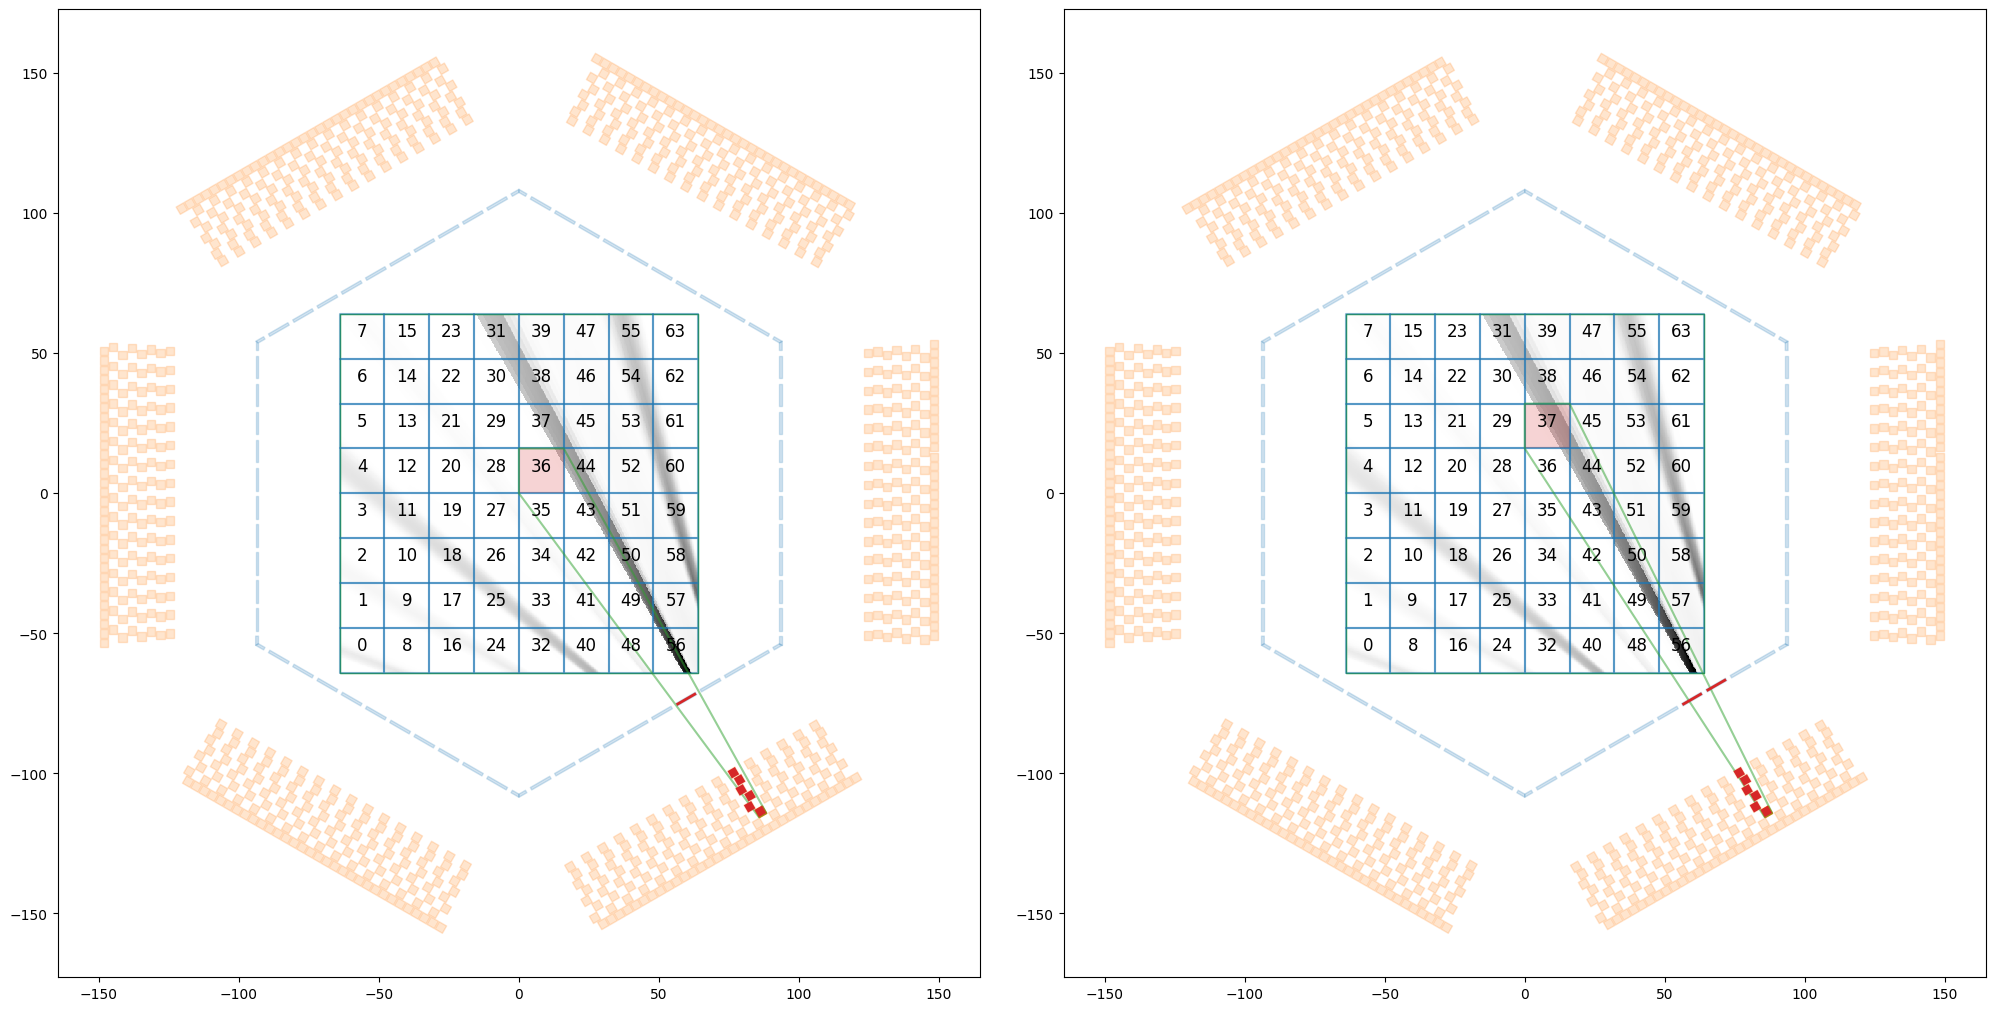

In [13]:
plt.close("all")
fig, axs = plt.subplots(1, 2, figsize=(20, 10), layout="constrained")
axs = axs.ravel()
for ax_idx, sfov_hull_idx in enumerate([36, 37]):
    ax = axs[ax_idx]
    for sfov_idx, ppdf_sfov in enumerate(ppdf_sfov_list):
        sfov_corners = sfov_corners_batch[sfov_idx].cpu().numpy()
        sfov_center = sfov_corners.mean(axis=0)
        sfov_extent = (
            sfov_corners[:, 0].min(),
            sfov_corners[:, 0].max(),
            sfov_corners[:, 1].min(),
            sfov_corners[:, 1].max(),
        )
        ax.imshow(
            ppdf_sfov.cpu()
            .view(
                fov_dict["n pixels"][0] // fov_dict["n subdivisions"][0],
                fov_dict["n pixels"][1] // fov_dict["n subdivisions"][1],
            )
            .T,
            origin="lower",
            extent=sfov_extent,
            cmap="gray_r",
            interpolation="none",
            vmin=0,
            vmax=1e-3,
        )
        ax.annotate(
            f"{sfov_idx}",
            sfov_center,
            textcoords="offset points",
            xytext=(0, 0),
            ha="center",
            fontsize=12,
            color="black",
        )

    scanner_polycoll_dict = plot_scanner_from_vertices_2d_mpl(
        plate_objects_vertices,
        crystal_objects_vertices,
        ax,
        fov_dict,
        plate_alpha=0.2,
        crystal_alpha=0.2,
        fov_alpha=1,
    )
    selected_crystal_polycoll = plot_polygons_from_vertices_mpl(
        crystal_objects_vertices[crystal_idx : crystal_idx + 1], ax, color="C1"
    )

    # Plot the SFOV frame
    sfov_polycoll = plot_polygons_from_vertices_mpl(
        sfov_corners_batch, ax, ec="C0", fc="none", linewidth=1.5, alpha=0.5
    )
    selected_sfov_idx = sfov_hull_idx
    selected_sfov_polycoll = plot_polygons_from_vertices_mpl(
        sfov_corners_batch[selected_sfov_idx : selected_sfov_idx + 1],
        ax,
        ec="none",
        fc="C3",
        alpha=0.2,
    )
    selected_sfov_crystal_ids = sfov_reduced_crystal_ids_list[selected_sfov_idx]
    print(
        f"Selected SFOV {selected_sfov_idx} reduced crystal IDs: {selected_sfov_crystal_ids}"
    )
    selected_sfov_hull = sfov_hull_list[selected_sfov_idx]
    selected_sfov_hull_polycoll = plot_polygons_from_vertices_mpl(
        selected_sfov_hull.unsqueeze(0),
        ax,
        ec="C2",
        fc="none",
        linewidth=1.5,
        alpha=0.5,
    )

    selected_sfov_reduced_crystals_polycoll = plot_polygons_from_vertices_mpl(
        crystal_objects_vertices[selected_sfov_crystal_ids],
        ax,
        fc="C3",
        ec="none",
        alpha=1,
    )
    selected_sfov_reduced_plates_polycoll = plot_polygons_from_vertices_mpl(
        plate_objects_vertices[sfov_reduced_plate_ids_list[selected_sfov_idx]],
        ax,
        fc="C3",
        ec="none",
        alpha=1,
    )

In [14]:
print(sfov_hull_list[36])

tensor([[   0.0000,    0.0000],
        [  85.6899, -115.6260],
        [  88.2880, -114.1260],
        [  16.0000,   16.0000],
        [   0.0000,   16.0000]])


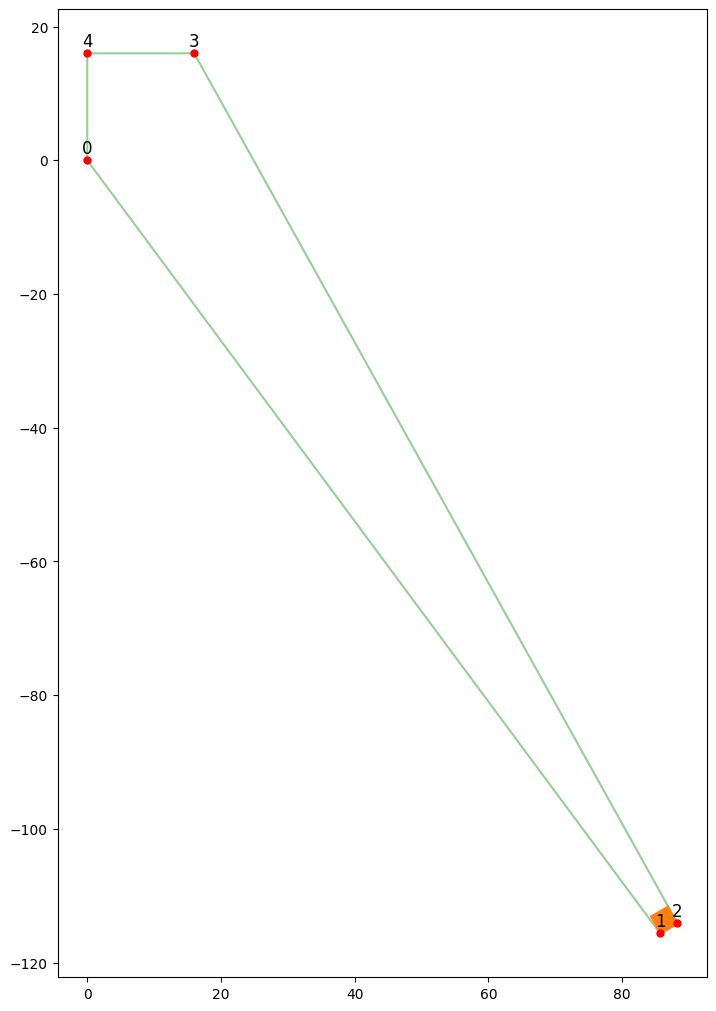

In [15]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
plot_polygons_from_vertices_mpl(
    sfov_hull_list[36].unsqueeze(0), ax, ec="C2", fc="none", linewidth=1.5, alpha=0.5
)
plot_polygons_from_vertices_mpl(crystal_objects_vertices[234:235], ax, color="C1")
ax.set_aspect("equal")
ax.autoscale()
for point_idx,point in enumerate(sfov_hull_list[36]):
    ax.plot(point[0].item(), point[1].item(), "ro", markersize=5)
    ax.annotate(
        f"{point_idx}",
        (point[0].item(), point[1].item()),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=12,
        color="black",
    )

In [16]:
from torch import arange, logical_or, sign


def polygons_hull_enclosed_2d_polygons_ids(
    polygon_vertices_batch: Tensor, hull, device=device("cpu")
) -> Tensor:
    # vertices_batch shape (n_batch, n_vertices, 2)
    # hull shape (n_hull, 2)
    n_batch = polygon_vertices_batch.shape[0]
    n_vertex = polygon_vertices_batch.shape[1]
    n_hull = hull.shape[0]
    eps_neg = 1e-11
    eps_pos = 1e-6
    p0_tensor = hull.unsqueeze(0).unsqueeze(0).expand(n_batch, n_vertex, n_hull, 2)
    p1_tensor = (
        hull.roll(-1, dims=0)
        .unsqueeze(0)
        .unsqueeze(0)
        .expand(n_batch, n_vertex, n_hull, 2)
    )
    p2_tensor = polygon_vertices_batch.unsqueeze(2).expand(n_batch, n_vertex, n_hull, 2)
    v1 = p1_tensor - p0_tensor
    v2 = p2_tensor - p0_tensor
    cross_prod = v2[:, :, :, 0] * v1[:, :, :, 1] - v2[:, :, :, 1] * v1[:, :, :, 0]
    cross_signs = sign(
        v2[:, :, :, 0] * v1[:, :, :, 1] - v2[:, :, :, 1] * v1[:, :, :, 0]
    ).view(n_batch, n_vertex, n_hull)
    print(f"Cross signs shape: {cross_signs.shape}")
    print(
        logical_or(
            (cross_signs > -eps_neg).all(dim=2), (cross_signs < eps_pos).all(dim=2)
        )
    )
    print(cross_signs[0, 2, :])
    print(cross_prod[0, 2, :])
    return arange(n_batch, device=device)[
        logical_or(
            (cross_signs >= -eps_neg).all(dim=2), (cross_signs <= eps_pos).all(dim=2)
        ).all(1)
    ]


enclosed_ids = polygons_hull_enclosed_2d_polygons_ids(
    crystal_objects_vertices[234:235], sfov_hull_list[36], device=default_device
)
print(f"Enclosed IDs: {enclosed_ids.tolist()}")

Cross signs shape: torch.Size([1, 4, 5])
tensor([[True, True, True, True]])
tensor([-1.,  0.,  0., -1., -1.])
tensor([ -428.9414,     0.0000,     0.0000, -2082.0156, -1412.6079])
Enclosed IDs: [0]


In [17]:
print(f"sfov_hull_list[36] shape: {sfov_hull_list[36].shape}")
print(f"sfov_hull_list[37] shape: {sfov_hull_list[37].shape}")

sfov_hull_list[36] shape: torch.Size([5, 2])
sfov_hull_list[37] shape: torch.Size([5, 2])


In [18]:
print(sfov_hull_list[36][[4,5]])
print(crystal_objects_vertices[234][2])

IndexError: index 5 is out of bounds for dimension 0 with size 5

In [ ]:

v1_tensor= (sfov_hull_list[36].roll(1, dims=0) - sfov_hull_list[36]).unsqueeze(0).expand(4,-1, 2)
print(sfov_hull_list[36])
print(sfov_hull_list[36].roll(1, dims=0))
v2_tensor = crystal_objects_vertices[234].unsqueeze(1).expand(-1, 6, 2) - sfov_hull_list[36].unsqueeze(0).expand(4, -1, 2)
print(f"v2 shape: {v2_tensor.shape}")
print(f"v1 shape: {v1_tensor.shape}")
# v2 = crystal_objects_vertices[234][2] - sfov_hull_list[36][4]
cross_prods = v2_tensor[:,:,0] * v1_tensor[:,:,1] - v2_tensor[:,:,1] * v1_tensor[:,:,0]
print(f"Cross product: {cross_prods[2,:].tolist()}")
print(v1_tensor.tolist())
print(v2_tensor.tolist())
v1 = sfov_hull_list[36][3]- sfov_hull_list[36][4]
v2 = crystal_objects_vertices[234][2] - sfov_hull_list[36][3]
cross_prod = v2[0] * v1[1] - v2[1] * v1[0]
print(f"Cross product: {cross_prod}")
print(f"Cross product: {cross_prods[2,4].item()}")

tensor([[   0.0000,    0.0000],
        [  85.6899, -115.6260],
        [  88.2880, -114.1260],
        [  86.7880, -111.5279],
        [  16.0000,   16.0000],
        [   0.0000,   16.0000]])
tensor([[   0.0000,   16.0000],
        [   0.0000,    0.0000],
        [  85.6899, -115.6260],
        [  88.2880, -114.1260],
        [  86.7880, -111.5279],
        [  16.0000,   16.0000]])
v2 shape: torch.Size([4, 6, 2])
v1 shape: torch.Size([4, 6, 2])
Cross product: [1412.60791015625, 428.9407958984375, 0.0, 0.0, -7.37890625, 2082.015625]
[[[0.0, 16.0], [-85.68991088867188, 115.6259765625], [-2.59808349609375, -1.5], [1.5, -2.59808349609375], [70.78799438476562, -127.52789306640625], [16.0, 0.0]], [[0.0, 16.0], [-85.68991088867188, 115.6259765625], [-2.59808349609375, -1.5], [1.5, -2.59808349609375], [70.78799438476562, -127.52789306640625], [16.0, 0.0]], [[0.0, 16.0], [-85.68991088867188, 115.6259765625], [-2.59808349609375, -1.5], [1.5, -2.59808349609375], [70.78799438476562, -127.52789306

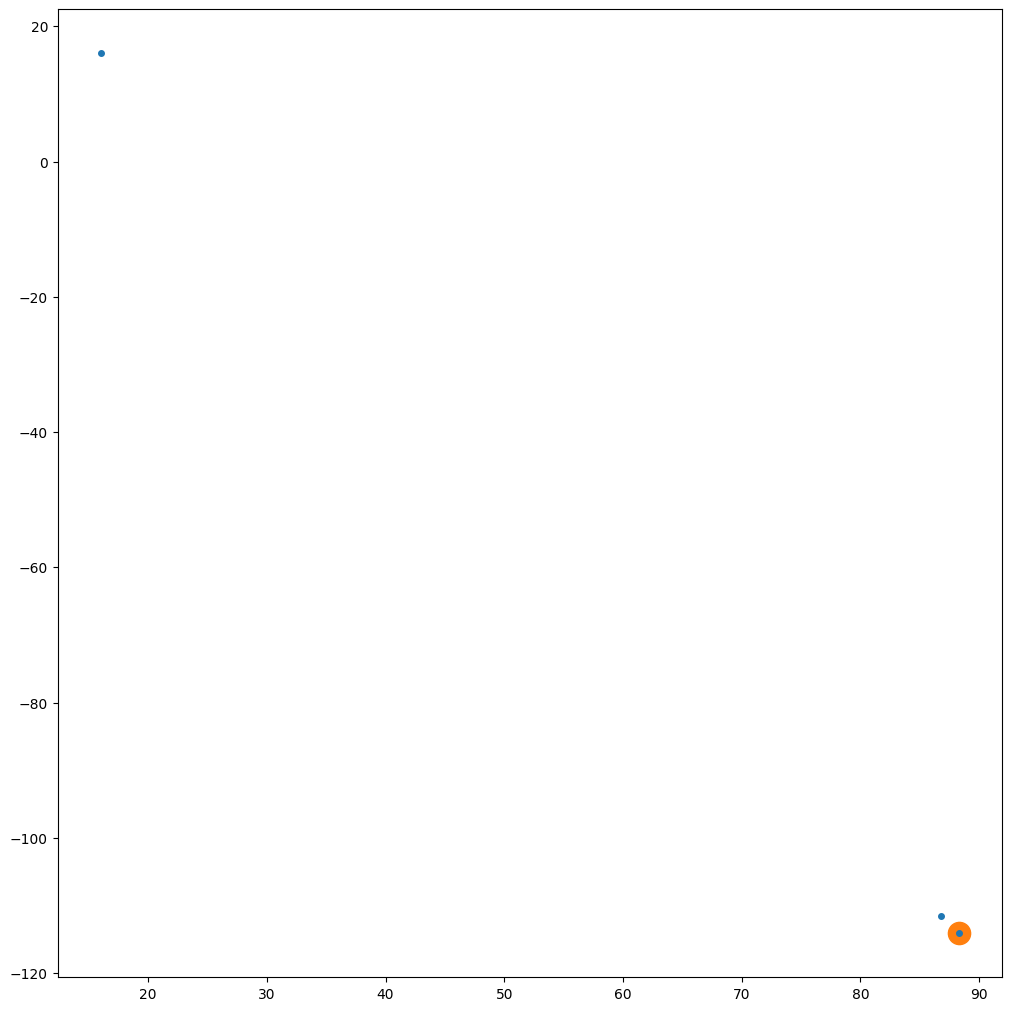

In [ ]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
ax.plot(crystal_objects_vertices[234][2, 0], crystal_objects_vertices[234][2, 1], "C1o", markersize=16)
ax.plot(sfov_hull_list[36][[2,3,4]][:,0], sfov_hull_list[36][[2,3,4]][:,1], "C0o", markersize=4)


In [ ]:
print(v1_tensor[2, 4, :].tolist())
print(v2_tensor[2, 4, :].tolist())

[70.78799438476562, -127.52789306640625]
[72.28799438476562, -130.1259765625]


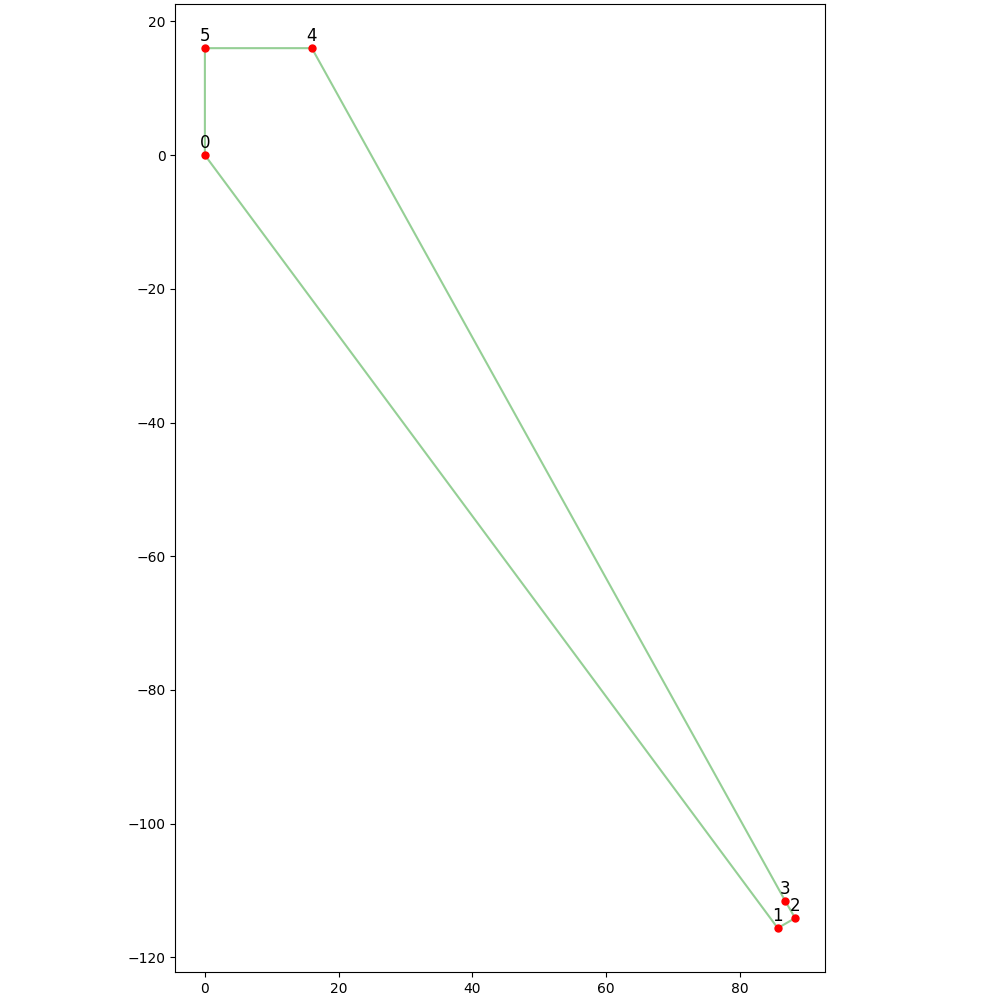

In [ ]:
%matplotlib widget

plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
plot_polygons_from_vertices_mpl(
    sfov_hull_list[36].unsqueeze(0), ax, ec="C2", fc="none", linewidth=1.5, alpha=0.5
)
# plot_polygons_from_vertices_mpl(crystal_objects_vertices[234:235], ax, color="C1")
ax.set_aspect("equal")
ax.autoscale()
for point_idx,point in enumerate(sfov_hull_list[36]):
    ax.plot(point[0].item(), point[1].item(), "ro", markersize=5)
    ax.annotate(
        f"{point_idx}",
        (point[0].item(), point[1].item()),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=12,
        color="black",
    )

In [ ]:
print(sfov_hull_list[36][[2,3,4]])

tensor([[  88.2880, -114.1260],
        [  86.7880, -111.5279],
        [  16.0000,   16.0000]])


In [ ]:
v1_tensor = (
    (sfov_hull_list[36] - sfov_hull_list[36].roll(1, dims=0))
    .unsqueeze(0)
    .expand(4, -1, 2)
)
v2_tensor = (
    (sfov_hull_list[36].roll(-1, dims=0) - sfov_hull_list[36])
    .unsqueeze(0)
    .expand(4, -1, 2)
)
print(f"v2 shape: {v2_tensor.shape}")
print(f"v1 shape: {v1_tensor.shape}")
# v2 = crystal_objects_vertices[234][2] - sfov_hull_list[36][4]
cross_prods = (
    v2_tensor[:, :, 0] * v1_tensor[:, :, 1] - v2_tensor[:, :, 1] * v1_tensor[:, :, 0]
)
print(f"Cross product: {cross_prods.tolist()}")

v2 shape: torch.Size([4, 6, 2])
v1 shape: torch.Size([4, 6, 2])
Cross product: [[-1371.03857421875, -428.9407958984375, -9.000038146972656, 7.37872314453125, -2040.4462890625, -256.0], [-1371.03857421875, -428.9407958984375, -9.000038146972656, 7.37872314453125, -2040.4462890625, -256.0], [-1371.03857421875, -428.9407958984375, -9.000038146972656, 7.37872314453125, -2040.4462890625, -256.0], [-1371.03857421875, -428.9407958984375, -9.000038146972656, 7.37872314453125, -2040.4462890625, -256.0]]


In [ ]:
test=arange(4)
print(test)
print(test.roll(1, dims=0))
print(test.roll(-1, dims=0))

tensor([0, 1, 2, 3])
tensor([3, 0, 1, 2])
tensor([1, 2, 3, 0])


In [ ]:
from torch import atan2, argsort, cat, unique as torch_unique, vstack, Tensor


def three_p_cross(points: Tensor) -> Tensor:
    """
    Calculate the cross product of three points in 2D space.
    Parameters
    ----------
    points : torch.Tensor, shape (3, 2)
        The three points to calculate the cross product from.
    Returns
    -------
    cross_product : torch.Tensor, shape (1,)
        The cross product of the three points.
    """
    v_1 = points[1] - points[0]
    v_2 = points[2] - points[0]
    return v_1[0] * v_2[1] - v_1[1] * v_2[0]


def sort_points_by_rad_2d(points: Tensor) -> Tensor:
    # sort the vertices by angle to point ref_point
    n_points = points.shape[1] - 1
    ref_point = points[0]

    rads = atan2(
        points[1:, 1] - ref_point[1],
        points[1:, 0] - ref_point[0],
    )
    # rads = rads + (rads < 0) * (2 * torch.pi)
    output = cat(
        (
            points[0].unsqueeze(0),
            points[1:][argsort(rads, dim=0)],
        )
    )
    return output


def sort_points_by_xy(points: Tensor) -> Tensor:
    # Get unique x values
    _, unique_x_index = torch_unique(points[:, 0], return_inverse=True, sorted=True)
    _, unique_y_index = torch_unique(points[:, 1], return_inverse=True, sorted=True)
    # Sort the indices based on x and y values
    indices_by_xy = argsort(unique_x_index * 100 + unique_y_index)
    return points[indices_by_xy]


def sort_points_for_hull_2d(points: Tensor):
    # Sort the points by x and y
    sorted_points = sort_points_by_xy(points)
    # Sort the points by angle reference to the first point
    output = sort_points_by_rad_2d(sorted_points)
    return output


def convex_hull_2d(sorted_points: Tensor):
    """
    Compute the convex hull of a set of 2D points using the Monotone Chain algorithm.
    Parameters
    ----------
    sorted_points : torch.Tensor, shape (n_points, 2)
        The sorted points to compute the convex hull from.
    Returns
    -------
    convex_hull : torch.Tensor, shape (n_hull_points, 2)
        The points of the convex hull.
    """

    # get the convex hull
    convex_hull = sorted_points[:2]
    for i in range(2, sorted_points.shape[0]):
        # convex_hull = vstack((convex_hull, sorted_points[i]))
        while (
            convex_hull.shape[0] > 2
            and three_p_cross(cat((convex_hull[-2:], sorted_points[i].unsqueeze(0)), dim=0)) < 0
        ):
            convex_hull = convex_hull[:-1]
        convex_hull = vstack((convex_hull, sorted_points[i]))
    return convex_hull


sfov_idx = 36
local_hull = convex_hull_2d(
    sort_points_for_hull_2d(
        cat(
            (
                sfov_corners_batch[sfov_idx],
                crystal_objects_vertices[crystal_idx],
            ),
            dim=0,
        )
    )
)
stacked_local_hull = cat(
    (
        local_hull.roll(1, dims=0).unsqueeze(1),
        local_hull.unsqueeze(1),
        local_hull.roll(-1, dims=0).unsqueeze(1),
    ),
    dim=1,
)
for points in stacked_local_hull:
    # print(f"Points: {points.tolist()}")
    print(f"Cross product: {three_p_cross(points).item()}")
# print(f"Local hull shape: {local_hull.shape}")
# print(f"Local hull: {local_hull.tolist()}")

Cross product: 1371.03857421875
Cross product: 428.94140625
Cross product: 446.5101318359375
Cross product: 2082.015625
Cross product: 256.0


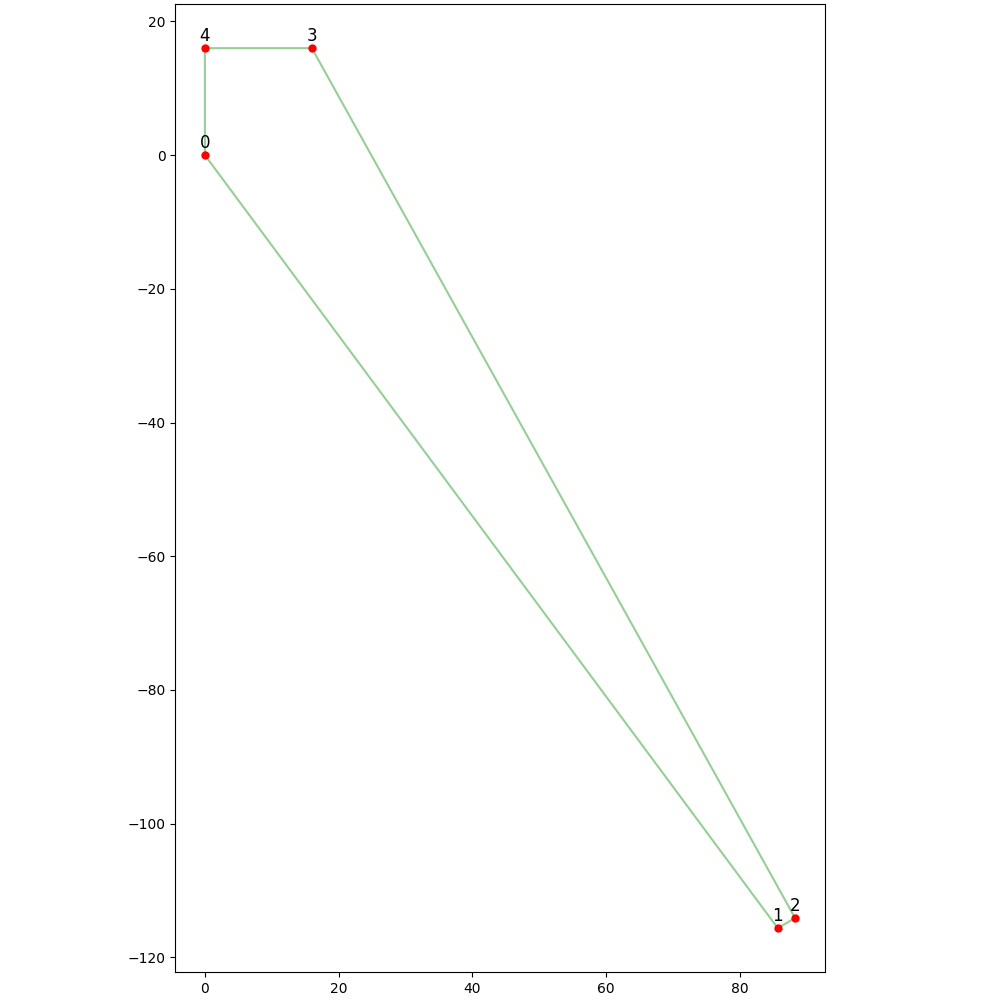

In [ ]:
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
plot_polygons_from_vertices_mpl(
   local_hull.unsqueeze(0), ax, ec="C2", fc="none", linewidth=1.5, alpha=0.5
)
# plot_polygons_from_vertices_mpl(crystal_objects_vertices[234:235], ax, color="C1")
ax.set_aspect("equal")
ax.autoscale()
for point_idx,point in enumerate(local_hull):
    ax.plot(point[0].item(), point[1].item(), "ro", markersize=5)
    ax.annotate(
        f"{point_idx}",
        (point[0].item(), point[1].item()),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=12,
        color="black",
    )

In [ ]:
stacked_local_hull=cat((local_hull.roll(1,dims=0).unsqueeze(1), local_hull.unsqueeze(1), local_hull.roll(-1, dims=0).unsqueeze(1)), dim=1)
print(f"Stacked local hull shape: {stacked_local_hull.shape}")
for points in stacked_local_hull:
    v1 = points[1] - points[0]
    v2 = points[2] - points[0]
    cross_prod = v1[0] * v2[1] - v1[1] * v2[0]
    print(f"Cross product: {cross_prod.item()}")
    print(three_p_cross(points).item())

Stacked local hull shape: torch.Size([6, 3, 2])
Cross product: 1371.03857421875
1371.03857421875
Cross product: 428.94140625
428.94140625
Cross product: 9.000038146972656
9.000038146972656
Cross product: -7.37872314453125
-7.37872314453125
Cross product: 2040.4462890625
2040.4462890625
Cross product: 256.0
256.0
